<a href="https://colab.research.google.com/github/alxmzr/Colab/blob/main/ETF_indicator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas_ta
import pandas as pd
import numpy as np
import pandas_ta as ta
from datetime import time

def calculate_indicators(df):
    df.ta.adx(append=True)
    df.ta.macd(append=True)
    df.ta.supertrend(append=True)
    df.ta.cci(append=True)
    df.ta.vwap(append=True)
    df.ta.linreg(append=True, length=14)
    df.ta.kc(append=True)
    df.ta.bbands(append=True)
    df.ta.psar(append=True)
    df.ta.mom(append=True)
    df.ta.willr(append=True)

    df['QQE'] = df.ta.rsi(length=14)
    df['Gann_High'] = df['high'].rolling(3).mean()
    df['Gann_Low'] = df['low'].rolling(3).mean()
    ichimoku = df.ta.ichimoku()[0]
    df = pd.concat([df, ichimoku], axis=1)
    df['Reflex'] = df['close'].diff(5)

    ema13 = df.ta.ema(length=13)
    df["Bulls_Power"] = df["high"] - ema13
    df["Bears_Power"] = df["low"] - ema13

    ha_df = ta.ha(df["open"], df["high"], df["low"], df["close"])
    df["HA_Close"], df["HA_Open"], df["HA_High"], df["HA_Low"] = ha_df["HA_close"], ha_df["HA_open"], ha_df["HA_high"], ha_df["HA_low"]

    def get_levels(df, freq):
        grouped = df.groupby(df.index.to_period(freq))
        df[f'High_{freq}'] = grouped['high'].transform('max').shift(1)
        df[f'Low_{freq}'] = grouped['low'].transform('min').shift(1)

    for f in ['D', 'W', 'M']: get_levels(df, f)

    sessions = {'Asia': (time(0,0), time(9,0)), 'London': (time(8,0), time(17,0)), 'NY': (time(13,0), time(22,0))}
    for name, (start, end) in sessions.items():
        df[f'is_{name}'] = df.index.map(lambda x: start <= x.time() <= end)
        df[f'S_{name}_H'] = df['high'].where(df[f'is_{name}']).groupby(df.index.date).cummax().shift(1)
        df[f'S_{name}_L'] = df['low'].where(df[f'is_{name}']).groupby(df.index.date).cummin().shift(1)

    df['LowestIrRange'] = df['low'].rolling(20).min().shift(1)
    df['HighestIrRange'] = df['high'].rolling(20).max().shift(1)
    return df

def generate_signals_and_score(df):
    bull = pd.Series(0.0, index=df.index)
    bear = pd.Series(0.0, index=df.index)

    # Weights
    W_LEVEL = 2.0
    W_TREND = 1.5
    W_OSC = 1.0

    # 1. Levels (W_LEVEL)
    for lvl in ['High_W', 'High_D', 'High_M', 'S_Asia_H', 'S_London_H', 'S_NY_H', 'HighestIrRange']:
        if lvl in df.columns:
            bull += ((df['high'] >= df[lvl]) & (df['high'].shift(1) < df[lvl])).astype(float) * W_LEVEL
    for lvl in ['Low_W', 'Low_D', 'Low_M', 'S_Asia_L', 'S_London_L', 'S_NY_L', 'LowestIrRange']:
        if lvl in df.columns:
            bear += ((df['low'] <= df[lvl]) & (df['low'].shift(1) > df[lvl])).astype(float) * W_LEVEL

    # 2. Key Trend (W_TREND)
    bull += (df['HA_Close'] > df['HA_Open']).astype(float) * W_TREND
    bull += (df['DMP_14'] > df['DMN_14']).astype(float) * W_TREND

    st_cols = [c for c in df.columns if "SUPERT_" in c and "d_" not in c]
    if st_cols: bull += (df['close'] > df[st_cols[0]]).astype(float) * W_TREND

    # 3. Oscillators / Power (W_OSC)
    bull += (df['Bulls_Power'] > 0).astype(float) * W_OSC
    if 'MACD_12_26_9' in df.columns: bull += (df['MACD_12_26_9'] > df['MACDs_12_26_9']).astype(float) * W_OSC
    if 'BBL_5_2.0' in df.columns: bull += (df['close'] < df['BBL_5_2.0']).astype(float) * W_OSC
    if 'PSARl_0.02_0.2' in df.columns: bull += (df['close'] > df['PSARl_0.02_0.2']).astype(float) * W_OSC

    # Normalize
    max_points = (7 * W_LEVEL) + (3 * W_TREND) + (4 * W_OSC)
    df['Bullish_Score'] = bull / max_points
    df['Bearish_Score'] = bear / max_points

    # ADX Filter > 25
    adx_filter = (df['ADX_14'] > 25)

    df['Decision'] = 'HOLD'
    df.loc[(df['Bullish_Score'] > 0.5) & adx_filter, 'Decision'] = 'BUY'
    df.loc[(df['Bearish_Score'] > 0.5) & adx_filter, 'Decision'] = 'SELL'
    return df

In [ ]:
!pip install yfinance

In [4]:
def backtest_strategy(df, initial_balance=10000, commission=0.001):
    balance = initial_balance
    position = 0  # 0: none, 1: long, -1: short
    entry_price = 0
    history = []

    for i in range(len(df)):
        current_price = df['close'].iloc[i]
        decision = df['Decision'].iloc[i]
        timestamp = df.index[i]
        bull_score = df['Bullish_Score'].iloc[i]
        bear_score = df['Bearish_Score'].iloc[i]

        # Exit conditions
        if position == 1 and (decision == 'SELL' or (decision == 'HOLD' and bull_score < 0.5)):
            profit_pct = (current_price - entry_price) / entry_price
            # Apply commission on exit
            exit_value = (balance * (1 + profit_pct)) * (1 - commission)
            balance = exit_value
            history.append({'time': timestamp, 'type': 'EXIT_LONG', 'price': current_price, 'profit': profit_pct - (commission*2), 'balance': balance})
            position = 0
        elif position == -1 and (decision == 'BUY' or (decision == 'HOLD' and bear_score < 0.5)):
            profit_pct = (entry_price - current_price) / entry_price
            # Apply commission on exit
            exit_value = (balance * (1 + profit_pct)) * (1 - commission)
            balance = exit_value
            history.append({'time': timestamp, 'type': 'EXIT_SHORT', 'price': current_price, 'profit': profit_pct - (commission*2), 'balance': balance})
            position = 0

        # Entry conditions
        if position == 0:
            if decision == 'BUY':
                position = 1
                # Apply commission on entry
                balance *= (1 - commission)
                entry_price = current_price
                history.append({'time': timestamp, 'type': 'BUY', 'price': entry_price, 'balance': balance})
            elif decision == 'SELL':
                position = -1
                # Apply commission on entry
                balance *= (1 - commission)
                entry_price = current_price
                history.append({'time': timestamp, 'type': 'SELL', 'price': entry_price, 'balance': balance})

    history_df = pd.DataFrame(history)
    total_return = (balance - initial_balance) / initial_balance * 100

    print(f"--- Backtest Results (Commission: {commission*100}%) ---")
    print(f"Initial Balance: {initial_balance}")
    print(f"Final Balance: {balance:.2f}")
    print(f"Total Return: {total_return:.2f}%")
    if not history_df.empty and 'profit' in history_df.columns:
        win_rate = (history_df['profit'] > 0).sum() / (history_df['profit'].notnull().sum()) * 100
        print(f"Win Rate (after fees): {win_rate:.2f}%")

    return history_df

In [5]:
import yfinance as yf

# 1. Тест для Forex (EUR/USD)
ticker_forex = "EURUSD=X"
data_forex = yf.download(ticker_forex, period="60d", interval="15m")
data_forex.columns = [col[0].lower() if isinstance(col, tuple) else col.lower() for col in data_forex.columns]
df_forex = calculate_indicators(data_forex.copy())
df_forex = generate_signals_and_score(df_forex)
print(f"--- Результати для {ticker_forex} ---")
results_forex = backtest_strategy(df_forex, commission=0.001)

# 2. Тест для BTC (BTC-USD) для прямого порівняння
ticker_btc = "BTC-USD"
data_btc = yf.download(ticker_btc, period="60d", interval="15m")
data_btc.columns = [col[0].lower() if isinstance(col, tuple) else col.lower() for col in data_btc.columns]
df_btc = calculate_indicators(data_btc.copy())
df_btc = generate_signals_and_score(df_btc)
print(f"\n--- Результати для {ticker_btc} ---")
results_btc = backtest_strategy(df_btc, commission=0.001)

display(results_forex.tail(5))

/tmp/ipykernel_9362/2289390521.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_forex = yf.download(ticker_forex, period="60d", interval="15m")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_9362/1540110195.py:23: Pandas4Warning: 'd' is deprecated and will be removed in a future version. Please use 'D' instead of 'd'.
  ichimoku = df.ta.ichimoku()[0]


--- Результати для EURUSD=X ---
--- Backtest Results (Commission: 0.1%) ---
Initial Balance: 10000
Final Balance: 8390.24
Total Return: -16.10%
Win Rate (after fees): 0.00%


/tmp/ipykernel_9362/2289390521.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_btc = yf.download(ticker_btc, period="60d", interval="15m")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_9362/1540110195.py:23: Pandas4Warning: 'd' is deprecated and will be removed in a future version. Please use 'D' instead of 'd'.
  ichimoku = df.ta.ichimoku()[0]



--- Результати для BTC-USD ---
--- Backtest Results (Commission: 0.1%) ---
Initial Balance: 10000
Final Balance: 8008.76
Total Return: -19.91%
Win Rate (after fees): 16.85%


,time,type,price,balance,profit
167,2026-05-06 08:45:00+00:00,EXIT_LONG,1.176747,8420.907898,-0.000588
168,2026-05-06 09:15:00+00:00,BUY,1.177302,8412.486990,NaN
169,2026-05-06 09:30:00+00:00,EXIT_LONG,1.177579,8406.053850,-0.001764
170,2026-05-06 10:30:00+00:00,BUY,1.178689,8397.647796,NaN
171,2026-05-06 11:00:00+00:00,EXIT_LONG,1.178828,8390.238610,-0.001882


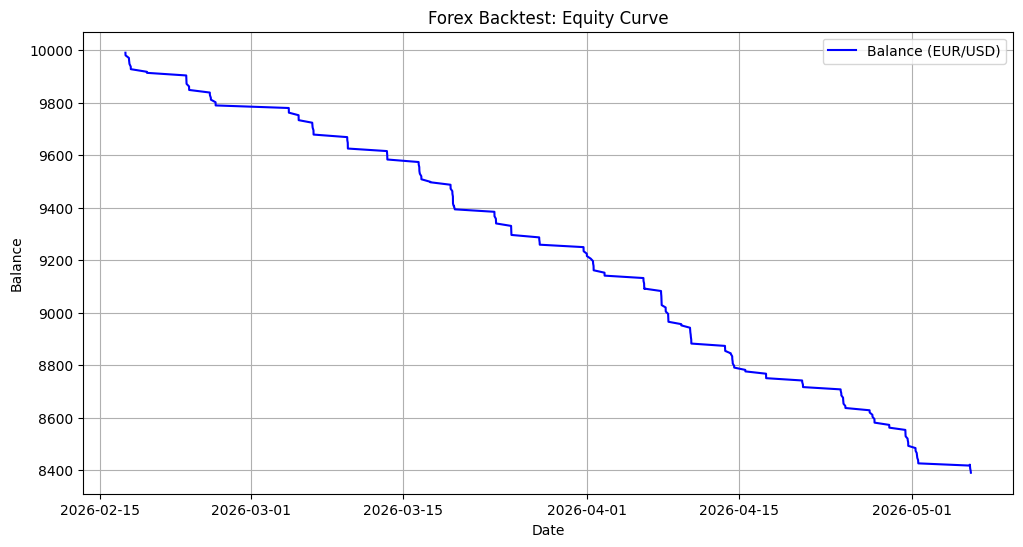

In [6]:
import matplotlib.pyplot as plt

if 'results_forex' in locals() and not results_forex.empty:
    plt.figure(figsize=(12, 6))
    plt.plot(results_forex['time'], results_forex['balance'], label='Balance (EUR/USD)', color='blue')
    plt.title('Forex Backtest: Equity Curve')
    plt.xlabel('Date')
    plt.ylabel('Balance')
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print('results_forex is not defined or empty. Please run the backtest cell first.')